# VOC2007 DINO training
Set `METHOD` to `baseline` or `gt_guided_aux`. All training logic is imported from Python modules.

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
from gt_guided_dino.api import ExperimentConfig, train
print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

torch: 2.12.1+cu126 cuda: True
NVIDIA GeForce RTX 3060


In [6]:
METHOD = 'gt_guided_aux'  # 'baseline' or 'gt_guided_aux'
config = ExperimentConfig(
    data_root=PROJECT_ROOT / 'VOC2007',
    output_root=PROJECT_ROOT / 'artifacts',
    method=METHOD,
)
config

ExperimentConfig(data_root=WindowsPath('D:/gt-guided_aux_loc_path/VOC2007'), output_root=WindowsPath('D:/gt-guided_aux_loc_path/artifacts'), torch_cache=WindowsPath('D:/gt-guided_aux_loc_path/weights/torch'), method='gt_guided_aux', seed=42, train_limit=1000, val_limit=None, epochs=12, batch_size=1, accumulation_steps=4, num_workers=0, precision='fp16', lr=0.0001, backbone_lr=1e-05, weight_decay=0.0001, grad_clip=0.1, lr_drop_epoch=11, lr_drop_gamma=0.1, save_every=1, num_queries=900, hidden_dim=256, enc_layers=6, dec_layers=6, dim_feedforward=2048, num_feature_levels=4, dn_number=100, train_scales=(480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800), train_max_size=1333, crop_resize_scales=(400, 500, 600), crop_min_size=384, crop_max_size=600, use_random_crop=True, val_size=800, val_max_size=1333, aux_weight=1.0, aux_l1_coef=5.0, aux_giou_coef=2.0, sampling_points_per_level=4)

In [7]:
# Existing latest.pt is resumed automatically. Use resume=False for a fresh run.
history = train(config, resume=True)
history[-1]

epoch=01 loss=45.1061 lr=1.00e-04 seconds=471.8


epoch=02 loss=30.7418 lr=1.00e-04 seconds=461.6


epoch=03 loss=24.7764 lr=1.00e-04 seconds=426.7


epoch=04 loss=21.7423 lr=1.00e-04 seconds=438.2


epoch=05 loss=19.5772 lr=1.00e-04 seconds=436.1


...

epoch=09 loss=15.6482 lr=1.00e-04 seconds=424.6


epoch=10 loss=15.0226 lr=1.00e-04 seconds=437.0


epoch=11 loss=14.2132 lr=1.00e-04 seconds=436.6


epoch=12 loss=12.4081 lr=1.00e-05 seconds=459.5


{'epoch': 12,
 'lr': 1e-05,
 'loss': 12.408121338248252,
 'batches': 1000,
 'optimizer_steps': 250,
 'seconds': 459.51189819999854,
 'peak_cuda_mb': 6023.619140625,
 'loss_ce': 0.3290090582072735,
 'loss_bbox': 0.05983678571786732,
 'loss_giou': 0.13215167014300824,
 'loss_aux_bbox': 0.07226865559071302,
 'loss_aux_giou': 0.18761867038533092,
 'aux_gate_mean': 0.69114599609375,
 'aux_offset_abs_mean': 0.334656494140625,
 'aux_attention_entropy': 2.1195387425422667}

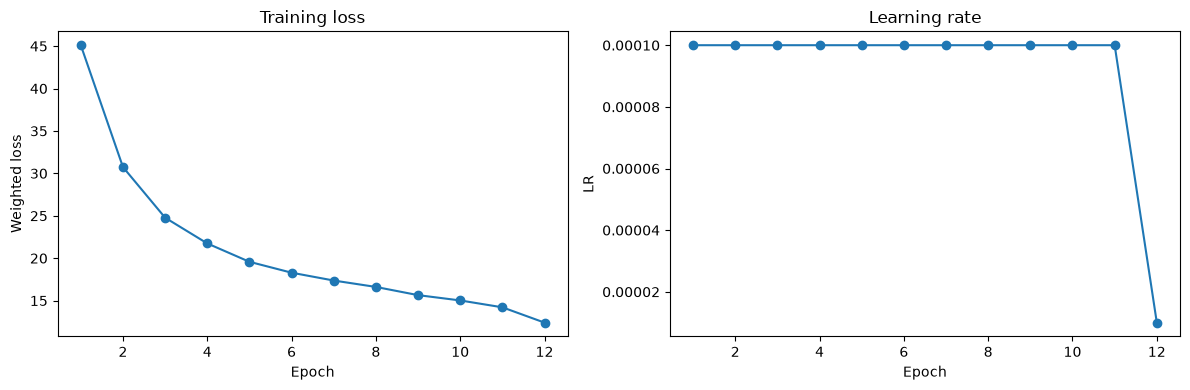

In [8]:
from gt_guided_dino.visualization import plot_history
plot_history(config.history_path);